# Fetch Weather Data — Shenzhen 2022

Descarga datos meteorológicos históricos de **Open-Meteo** (gratuito, sin API key) para Shenzhen, China durante el período del dataset ST-EVCDP: **19 Jun – 18 Jul 2022**.

- Fuente: [open-meteo.com/en/docs/historical-weather-api](https://open-meteo.com/en/docs/historical-weather-api)
- Variables: temperatura (°C), humedad relativa (%), precipitación (mm)
- Resolución original: **horaria** → interpolada a **5 minutos** (8640 timesteps) para coincidir con ST-EVCDP
- Output: `weather_shenzhen.csv`

Este CSV se carga en `ChatEV.ipynb` como feature adicional en los prompts (§3.1.1 del paper: *Weather conditions*).

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ── CONFIGURA AQUÍ tu ruta a los datasets ────────────────────────────
# None = auto-descubrir en Drive (Colab/extensión Colab)
# Si falla, pon la ruta manualmente: "/content/drive/MyDrive/tu_carpeta"
DATASETS_PATH_OVERRIDE = None

import os, glob

if DATASETS_PATH_OVERRIDE:
    DATASETS_PATH = DATASETS_PATH_OVERRIDE
    print(f"Usando ruta manual: {DATASETS_PATH}")
else:
    candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
    if candidates:
        DATASETS_PATH = os.path.dirname(candidates[0])
        print(f"Encontrado automáticamente: {DATASETS_PATH}")
    else:
        try:
            from google.colab import drive
            if not os.path.isdir("/content/drive/MyDrive"):
                drive.mount("/content/drive")
            candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
            if candidates:
                DATASETS_PATH = os.path.dirname(candidates[0])
                print(f"Encontrado tras montar Drive: {DATASETS_PATH}")
            else:
                print("ERROR: information.csv no encontrado en Drive.")
                print("Pon la ruta correcta en DATASETS_PATH_OVERRIDE arriba.")
                DATASETS_PATH = None
        except ImportError:
            print("No estás en Colab. Pon la ruta en DATASETS_PATH_OVERRIDE.")
            DATASETS_PATH = None

if DATASETS_PATH:
    test_file = f"{DATASETS_PATH}/information.csv"
    if os.path.exists(test_file):
        csvs = glob.glob(f"{DATASETS_PATH}/*.csv")
        print(f"OK — {len(csvs)} CSVs encontrados:")
        for c in sorted(csvs):
            print(f"  {os.path.basename(c)}")
    else:
        print(f"AVISO: information.csv no encontrado en {DATASETS_PATH}")

Encontrado automáticamente: /content/drive/MyDrive/datasets
OK — 11 CSVs encontrados:
  addresses_shenzhen.csv
  adj.csv
  calendar_features.csv
  distance.csv
  duration.csv
  information.csv
  occupancy.csv
  price.csv
  stations.csv
  time.csv
  volume.csv


In [3]:
# Coordenadas de Shenzhen (centro urbano)
LAT = 22.5431
LON = 114.0579

# Período exacto del dataset ST-EVCDP
START_DATE = "2022-06-19"
END_DATE   = "2022-07-18"

# Variables meteorológicas del paper (§3.1.1)
VARIABLES = "temperature_2m,relativehumidity_2m,precipitation"

url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LAT}&longitude={LON}"
    f"&start_date={START_DATE}&end_date={END_DATE}"
    f"&hourly={VARIABLES}"
    f"&timezone=Asia%2FShanghai"
)

print(f"Fetching: {url[:100]}...")
resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.json()

print(f"Status: OK")
print(f"Keys: {list(data.keys())}")
print(f"Hourly rows: {len(data['hourly']['time'])}")

Fetching: https://archive-api.open-meteo.com/v1/archive?latitude=22.5431&longitude=114.0579&start_date=2022-06...
Status: OK
Keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']
Hourly rows: 720


In [4]:
# Construir DataFrame horario
hourly = data["hourly"]

df_hourly = pd.DataFrame({
    "timestamp":    pd.to_datetime(hourly["time"]),
    "temperature":  hourly["temperature_2m"],
    "humidity":     hourly["relativehumidity_2m"],
    "precipitation":hourly["precipitation"],
})

df_hourly = df_hourly.set_index("timestamp")

print(f"Hourly data shape: {df_hourly.shape}")
print(f"Range: {df_hourly.index[0]}  →  {df_hourly.index[-1]}")
print(f"\nStats:")
print(df_hourly.describe().round(2))

Hourly data shape: (720, 3)
Range: 2022-06-19 00:00:00  →  2022-07-18 23:00:00

Stats:
       temperature  humidity  precipitation
count       720.00    720.00         720.00
mean         27.67     85.43           0.33
std           1.91      9.23           0.83
min          24.50     57.00           0.00
25%          26.20     80.00           0.00
50%          27.20     89.00           0.00
75%          29.00     93.00           0.20
max          33.00     99.00           8.10


In [5]:
# Interpolar de horario → 5 minutos (×12) para coincidir con ST-EVCDP
# ST-EVCDP: 8640 timesteps = 30 días × 288 pasos/día (cada 5 min)

TARGET_TIMESTEPS = 8640

df_5min = df_hourly.resample("5min").interpolate(method="linear")

# Recortar exactamente a 8640 filas
df_5min = df_5min.iloc[:TARGET_TIMESTEPS].copy()

# Si faltan filas (raro), rellenar con forward-fill
if len(df_5min) < TARGET_TIMESTEPS:
    extra = pd.DataFrame(
        index=pd.date_range(df_5min.index[-1], periods=TARGET_TIMESTEPS - len(df_5min) + 1, freq="5min")[1:],
        columns=df_5min.columns,
    )
    df_5min = pd.concat([df_5min, extra]).ffill()

# Resetear índice para guardar timestamp como columna
df_5min = df_5min.reset_index()
df_5min.columns = ["timestamp", "temperature", "humidity", "precipitation"]

print(f"5-min data shape: {df_5min.shape}  (target: {TARGET_TIMESTEPS} rows)")
print(f"NaN values: {df_5min.isnull().sum().sum()}")
print(f"\nMuestra (primeras 3 filas):")
print(df_5min.head(3).to_string())

5-min data shape: (8640, 4)  (target: 8640 rows)
NaN values: 0

Muestra (primeras 3 filas):
            timestamp  temperature  humidity  precipitation
0 2022-06-19 00:00:00         26.5      90.0            0.0
1 2022-06-19 00:05:00         26.5      90.0            0.0
2 2022-06-19 00:10:00         26.5      90.0            0.0


/tmp/ipykernel_16537/2946042553.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_5min = pd.concat([df_5min, extra]).ffill()


Preview guardado: weather_shenzhen_preview.png


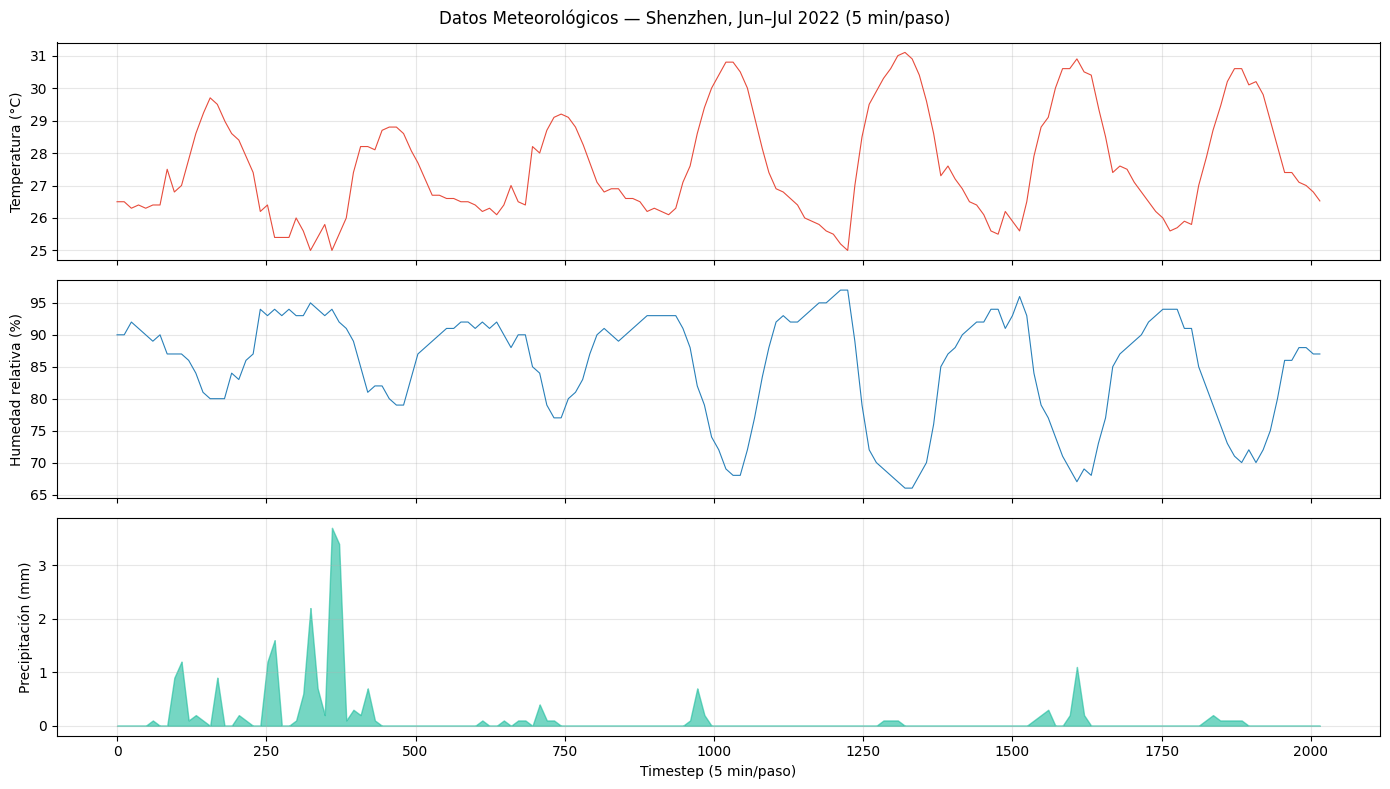

In [6]:
# Validación visual
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Datos Meteorológicos — Shenzhen, Jun–Jul 2022 (5 min/paso)", fontsize=12)

n_show = 288 * 7  # primera semana

axes[0].plot(df_5min["temperature"][:n_show], color="#E74C3C", lw=0.8)
axes[0].set_ylabel("Temperatura (°C)")
axes[0].grid(alpha=0.3)

axes[1].plot(df_5min["humidity"][:n_show], color="#2980B9", lw=0.8)
axes[1].set_ylabel("Humedad relativa (%)")
axes[1].grid(alpha=0.3)

axes[2].fill_between(range(n_show), df_5min["precipitation"][:n_show], color="#1ABC9C", alpha=0.6)
axes[2].set_ylabel("Precipitación (mm)")
axes[2].set_xlabel("Timestep (5 min/paso)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("weather_shenzhen_preview.png", dpi=130, bbox_inches="tight")
print("Preview guardado: weather_shenzhen_preview.png")
plt.show()

In [7]:
# Guardar CSV
OUT_PATH = "weather_shenzhen.csv"
df_5min.to_csv(OUT_PATH, index=False)

size_kb = Path(OUT_PATH).stat().st_size / 1024
print(f"Guardado: {OUT_PATH}")
print(f"Tamaño:   {size_kb:.1f} KB")
print(f"Filas:    {len(df_5min)}")
print(f"Columnas: {list(df_5min.columns)}")
print(f"\nListo para importar en ChatEV.ipynb (Sección 1.5)")

Guardado: weather_shenzhen.csv
Tamaño:   436.3 KB
Filas:    8640
Columnas: ['timestamp', 'temperature', 'humidity', 'precipitation']

Listo para importar en ChatEV.ipynb (Sección 1.5)


In [8]:
# Copiar a Drive si Colab y DATASETS_PATH disponible
try:
    import shutil, os
    if 'DATASETS_PATH' in dir() and DATASETS_PATH and os.path.isdir(DATASETS_PATH):
        dst = f"{DATASETS_PATH}/weather_shenzhen.csv"
        shutil.copy(OUT_PATH, dst)
        print(f"Copiado a Drive: {dst}")
        print("weather_shenzhen.csv está junto al resto de CSVs del dataset.")
    else:
        print("DATASETS_PATH no disponible — CSV guardado solo localmente.")
        print("Cópialo manualmente a la carpeta de datasets antes de ejecutar ChatEV.ipynb.")
except Exception as e:
    print(f"No se pudo copiar: {e}")

Copiado a Drive: /content/drive/MyDrive/datasets/weather_shenzhen.csv
weather_shenzhen.csv está junto al resto de CSVs del dataset.
